# Testing the Framework and Code Snippet of the Project
# Quant Predictive MOdel

In [1]:
# First of all, import the libraries we will need
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

print("All libraries loaded successfully")

C:\Users\u\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries loaded successfully


In [2]:
# Fetching the data, Selecting a Ticker and running our EDA
ticker = "AAPL"
df = yf.download(ticker, period="1y")
df = yf.download(ticker, start="2020-01-01", end="2026-01-01")

# Always look at your data first
print(df.shape)
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(1508, 5)
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400505  72.460769  71.156667  71.409770  135480400
2020-01-03  71.696655  72.455974  71.472477  71.629160  146322800
2020-01-06  72.267929  72.306499  70.568503  70.819201  118387200
2020-01-07  71.928062  72.533103  71.708703  72.277586  108872000
2020-01-08  73.085106  73.386423  71.631552  71.631552  132079200
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-12-24  273.554016  275.172497  271.945536  272.085389  17910600
2025-12-26  273.144409  275.112569  272.604905  273.903708  21521800
2025-12-29  273.504089  274.103504  272.095404  272.435082  23715200
2025-12-30  272.824707  273.823772  272.025467  


Missing values per column:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


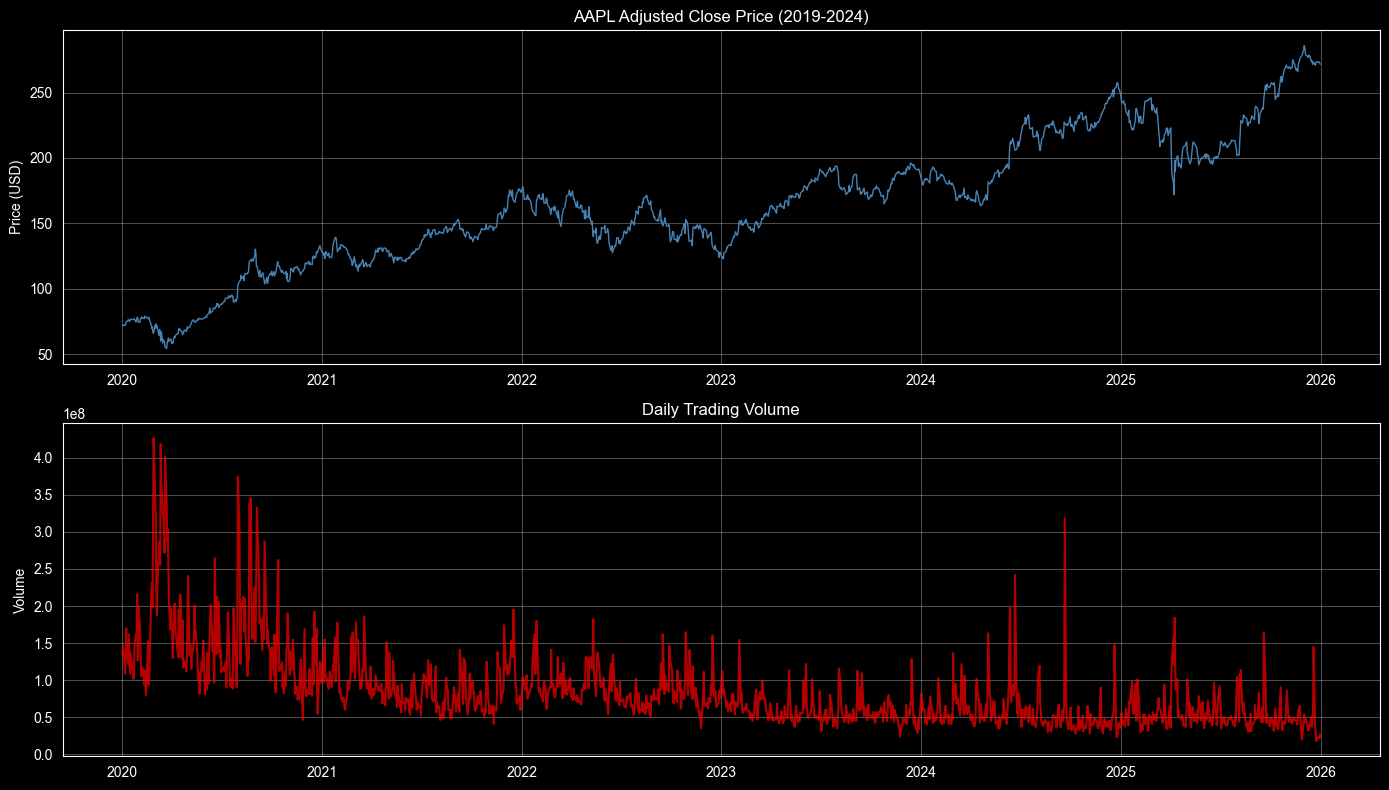

In [3]:
# Check for missing data
print("\nMissing values per column:")
print(df.isnull().sum())

# Visualize the price history
# Watch to catch patterns that statistics miss.
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Price chart
axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0].set_title(f'{ticker} Adjusted Close Price (2019-2024)')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)

# Volume chart (Market activity)
axes[1].plot(df.index, df['Volume'], color='red', alpha=0.7)
axes[1].set_title('Daily Trading Volume')
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Create technical indicator features
# We work on a copy to preserve our original data.
features = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
features.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# Moving Averages
# A 10-day SMA shows the short-term trend.
# A 50-day SMA shows the medium-term trend.
# When the short MA crosses above the long MA, it's often a bullish signal.
features['SMA_10'] = features['Close'].rolling(window=10).mean()
features['SMA_50'] = features['Close'].rolling(window=50).mean()

# The ratio is more useful than the raw values — it's scale-invariant.
features['SMA_ratio'] = features['SMA_10'] / features['SMA_50']

# RSI: Relative Strength Index
# RSI measures momentum. Above 70 = overbought, below 30 = oversold.
# This is the most widely used momentum indicator in finance.

def compute_rsi(series, period=14):
    delta = series.diff()                          # Daily price changes
    gain = delta.clip(lower=0)                     # Only keep positive changes
    loss = -delta.clip(upper=0)                    # Only keep negative changes (as positive)
    avg_gain = gain.rolling(window=period).mean()  # Average gain over the period
    avg_loss = loss.rolling(window=period).mean()  # Average loss over the period
    rs = avg_gain / avg_loss                       # Relative strength ratio
    return 100 - (100 / (1 + rs))                  # Normalized to 0-100

features['RSI_14'] = compute_rsi(features['Close'])

#  Bollinger Bands
# Price channel around a moving average. Wide bands = high volatility.
# When price hits the upper band, it may be overbought.
bb_window = 20
features['BB_mid'] = features['Close'].rolling(window=bb_window).mean()
bb_std = features['Close'].rolling(window=bb_window).std()
features['BB_upper'] = features['BB_mid'] + (2 * bb_std)
features['BB_lower'] = features['BB_mid'] - (2 * bb_std)
# The position within the band (0 = at lower, 1 = at upper)
features['BB_position'] = (features['Close'] - features['BB_lower']) / \
                           (features['BB_upper'] - features['BB_lower'])

# Volatility
# Daily returns and their rolling standard deviation.
features['Daily_return'] = features['Close'].pct_change()          # % change day-over-day
features['Volatility_10'] = features['Daily_return'].rolling(10).std()  # 10-day volatility

# Volume signal
# Is today's volume above or below the recent average?
# High-volume moves are more "real" than low-volume ones.
features['Volume_ratio'] = features['Volume'] / features['Volume'].rolling(20).mean()

# Lag features
# Yesterday's return is a feature for predicting today. This is key for time series.
features['Return_lag1'] = features['Daily_return'].shift(1)  # Yesterday's return
features['Return_lag2'] = features['Daily_return'].shift(2)  # Two days ago

print(f"Feature set shape: {features.shape}")
print(features.tail(10))

Feature set shape: (1508, 18)
                  Open        High         Low       Close     Volume  \
Date                                                                    
2025-12-17  274.752927  275.901845  271.386082  271.585876   50138700   
2025-12-18  273.354202  273.374203  266.700455  271.935547   51630700   
2025-12-19  271.895586  274.343308  269.647689  273.414185  144632000   
2025-12-22  272.604892  273.623958  270.257113  270.716675   36571800   
2025-12-23  270.586809  272.245261  269.308007  272.105377   29642000   
2025-12-24  272.085389  275.172497  271.945536  273.554016   17910600   
2025-12-26  273.903708  275.112569  272.604905  273.144409   21521800   
2025-12-29  272.435082  274.103504  272.095404  273.504089   23715200   
2025-12-30  272.554970  273.823772  272.025467  272.824707   22139600   
2025-12-31  272.804725  273.424141  271.495952  271.605835   27293600   

                SMA_10      SMA_50  SMA_ratio     RSI_14      BB_mid  \
Date                 

In [5]:
# Create the target variable
# Target = 1 if tomorrow's close is HIGHER than today's, else 0.
# We use .shift(-1) to look at the NEXT day's price.
features['Target'] = (features['Close'].shift(-1) > features['Close']).astype(int)

# Drop rows with NaN values (from rolling windows and shifts)
# Rolling(50) creates 49 NaN rows at the start, for example.
features.dropna(inplace=True)

print(f"\nDataset after cleaning: {features.shape[0]} trading days")
print(f"\nClass distribution (0=down, 1=up):")
print(features['Target'].value_counts(normalize=True).round(3))
# You want a roughly 50/50 split. If it's very imbalanced, you need special techniques.


Dataset after cleaning: 1459 trading days

Class distribution (0=down, 1=up):
Target
1    0.533
0    0.467
Name: proportion, dtype: float64


In [6]:
# Split into features (X) and target (y)
feature_cols = ['SMA_ratio', 'RSI_14', 'BB_position', 'Volatility_10',
                'Volume_ratio', 'Return_lag1', 'Return_lag2']

X = features[feature_cols]
y = features['Target']

# CRITICAL: Time-series split (NOT random split!)
# Time order is very crucial for Finance data
# You CANNOT train on 2022 data and test on 2021 — that's cheating.
# We use the last 20% of time as our test set.
split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set: {len(X_train)} days")
print(f"Test set:     {len(X_test)} days")

#  Scale features
# Many ML algorithms assume features are on similar scales.
# StandardScaler transforms each feature to mean=0, std=1.
# We fit ONLY on training data, then apply to both — never let test data influence the scaler.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # only transform on test

Training set: 1167 days
Test set:     292 days


In [7]:
# Train three models (simplest to most powerful)

# Model 1: Logistic Regression — the humble baseline
# It finds a linear boundary between "up" and "down" days.
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# Model 2: Random Forest — ensemble of decision trees
# Each tree sees a random subset of data and features.
# The majority vote across 200 trees is very robust to overfitting.
rf_model = RandomForestClassifier(n_estimators=200, max_depth=5,
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

# Model 3: XGBoost — the current king of tabular ML
# Builds trees sequentially, each one correcting the errors of the previous.
# 'use_label_encoder=False' and 'eval_metric' suppress warnings.
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                               random_state=42, eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

In [8]:
# Compare model performance
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": lr_preds,
    "Random Forest":       rf_preds,
    "XGBoost":             xgb_preds
}

for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    print(f"\n{'='*40}")
    print(f"{name} — Accuracy: {acc:.3f}")
    print(classification_report(y_test, preds, target_names=['Down', 'Up']))


Logistic Regression — Accuracy: 0.545
              precision    recall  f1-score   support

        Down       0.57      0.06      0.11       135
          Up       0.54      0.96      0.69       157

    accuracy                           0.54       292
   macro avg       0.56      0.51      0.40       292
weighted avg       0.56      0.54      0.42       292


Random Forest — Accuracy: 0.503
              precision    recall  f1-score   support

        Down       0.43      0.24      0.31       135
          Up       0.53      0.73      0.61       157

    accuracy                           0.50       292
   macro avg       0.48      0.49      0.46       292
weighted avg       0.48      0.50      0.47       292


XGBoost — Accuracy: 0.541
              precision    recall  f1-score   support

        Down       0.50      0.51      0.51       135
          Up       0.57      0.57      0.57       157

    accuracy                           0.54       292
   macro avg       0.54      

Strategy Sharpe Ratio:    -1.037
Buy-and-Hold Sharpe Ratio: 0.473


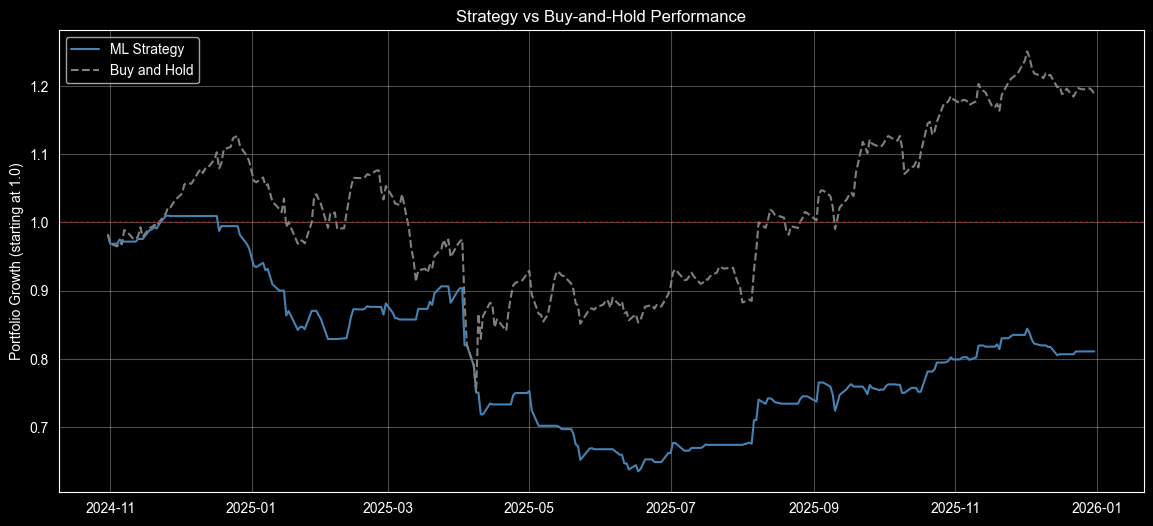

In [9]:
# Backtesting — does the model make money?
# Accuracy alone doesn't tell you if the model is profitable.

# Get XGBoost's probability estimates (not just 0/1 predictions)
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]  # Probability of "Up"

# Build a simple backtest: go long when model says "Up" (proba > 0.5)
backtest = pd.DataFrame({
    'Date':         X_test.index,
    'Actual_return': features.loc[X_test.index, 'Daily_return'],
    'Signal':        (xgb_proba > 0.5).astype(int)  # 1 = buy, 0 = stay out
})

# Strategy return = signal * actual return
backtest['Strategy_return'] = backtest['Signal'] * backtest['Actual_return']
# Buy-and-hold benchmark: just hold the stock every day
backtest['Cumulative_buyhold']  = (1 + backtest['Actual_return']).cumprod()
backtest['Cumulative_strategy'] = (1 + backtest['Strategy_return']).cumprod()

# Sharpe Ratio: return per unit of risk (higher is better; >1 is good, >2 is great)
def sharpe_ratio(returns, risk_free_rate=0.05/252):
    excess = returns - risk_free_rate
    return (excess.mean() / excess.std()) * np.sqrt(252)  # Annualized

sr_strategy  = sharpe_ratio(backtest['Strategy_return'])
sr_benchmark = sharpe_ratio(backtest['Actual_return'])

print(f"Strategy Sharpe Ratio:    {sr_strategy:.3f}")
print(f"Buy-and-Hold Sharpe Ratio: {sr_benchmark:.3f}")

# Plot the equity curves
plt.figure(figsize=(14, 6))
plt.plot(backtest['Date'], backtest['Cumulative_strategy'],  label='ML Strategy',   color='steelblue')
plt.plot(backtest['Date'], backtest['Cumulative_buyhold'],   label='Buy and Hold',  color='gray', linestyle='--')
plt.axhline(1, color='red', linestyle=':', alpha=0.5)
plt.title('Strategy vs Buy-and-Hold Performance')
plt.ylabel('Portfolio Growth (starting at 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

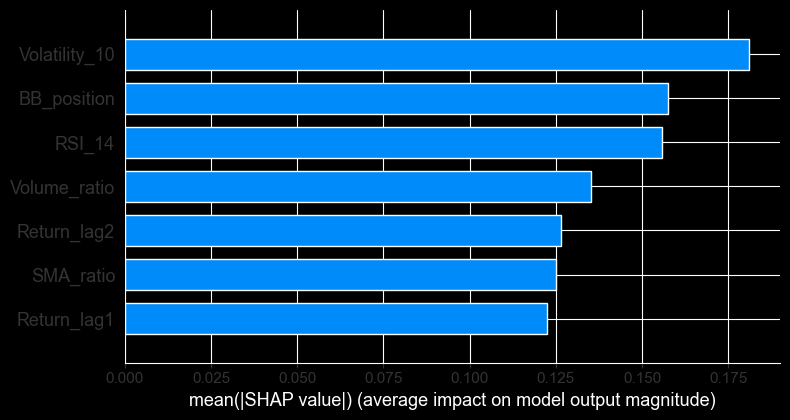

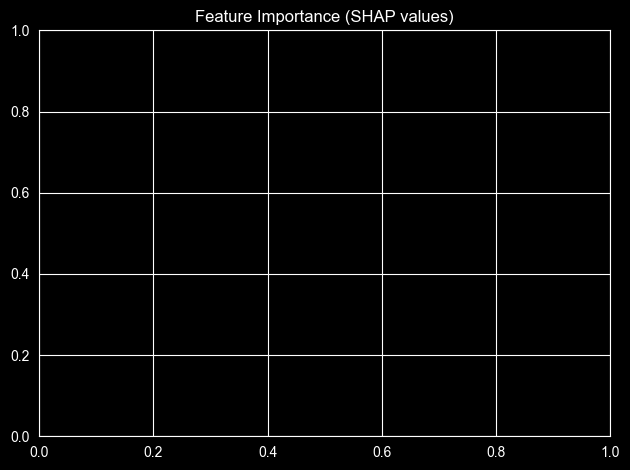

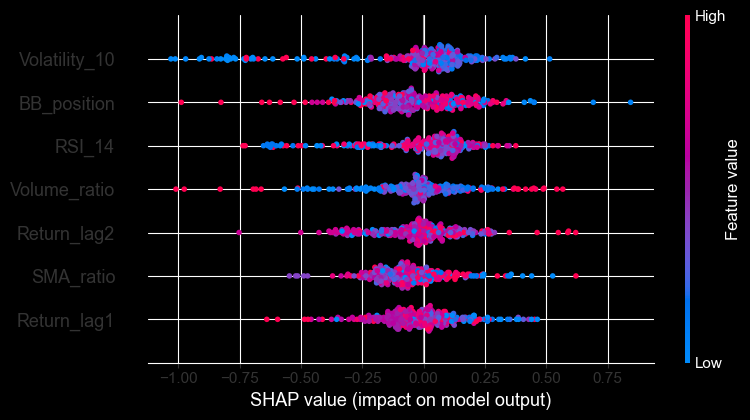

In [10]:
# Explainability with SHAP
# SHAP (SHapley Additive exPlanations) tells you HOW MUCH each feature
# contributed to each individual prediction. This is crucial in finance
# because regulators and PMs need to understand WHY a model is trading.

explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X_test_scaled)

# Summary plot: which features matter most overall?
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type="bar")
plt.title("Feature Importance (SHAP values)")
plt.tight_layout()
plt.show()

# Detailed plot: how does each feature's VALUE affect predictions?
# Red = high feature value, Blue = low feature value
# Right = pushes model toward predicting "Up", Left = toward "Down"
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)